# Single-event pipeline walkthrough

Walk one event through the reconstruction pipeline step by step and inspect how the event object changes after each stage.

## Bootstrap project imports

In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in (NOTEBOOK_DIR, *NOTEBOOK_DIR.parents):
    if (candidate / "src").exists() and (candidate / "notebooks").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate reco_algorithm_tests project root.")

src_dir = PROJECT_ROOT / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

print(f"Project root: {PROJECT_ROOT}")


Project root: /workdir/playground/reco_algorithm_tests


## Import reconstruction and plotting tools

In [2]:
import numpy as np
from tqdm.notebook import tqdm

from algorithms import (
    DefaultPatternFormer,
    DefaultTrackletFormer,
    OverlapVertexFormer,
    TrackletGroupingValidator,
    print_registered_algorithms,
)
from data_io import (
    AllowedAtarParticlesCut,
    AtarFiducialCut,
    DelayedLysoClusterCut,
    EmptyEventCut,
    NoElectronAtarHitsCut,
    RequirePionAtarHitCut,
    RecoDataFile,
    load_pioneer_libraries,
    print_file_creation_time,
    print_registered_cuts,
)
from figures import DetectorEventViewFigure, EventDisplayFigure, EventPatternsSummaryFigure, PatternClassificationFigure
from pipeline import Pipeline
from pipeline.stages import (
    EventInputStage,
    EventInitStage,
    InputContext,
    PatternStage,
    TrackletStage,
    ValidationStage,
    VertexStage,
)


## Load PIONEER shared libraries

In [3]:
load_pioneer_libraries()

## Locate the current smoke-test ROOT file

In [4]:
DATA_DIR = (PROJECT_ROOT / ".data" / "current").resolve()
reco_file = str(DATA_DIR / "all_rec.root")

print_file_creation_time(reco_file)


The file '/workdir/playground/reco_algorithm_tests/.data/current/all_rec.root' was created on: 2026-06-17 14:48:17


## Open the reconstructed data file

In [5]:
print_registered_cuts()

reco_data = RecoDataFile(
    reco_file,
    profile="realistic",
    cuts=[
        EmptyEventCut(enabled=True),
        AllowedAtarParticlesCut(enabled=True),
        NoElectronAtarHitsCut(enabled=True),
        RequirePionAtarHitCut(enabled=True),
        AtarFiducialCut(max_abs_coordinate=8.0, enabled=True),
        DelayedLysoClusterCut(
            min_cluster_energy_mev=10.0,
            window_start_ns=0.0,
            window_stop_ns=700.0,
            cluster_gap_ns=5.0,
            enabled=True,
        ),
    ],
)

print(f"Loaded {reco_data.entries} reconstructed events from {reco_file}")
print(f"Truth collections available: {reco_data.has_truth_entry}")
print("Enabled cuts:", [cut.name for cut in reco_data.cut_flow.enabled_cuts()])


cuts:
  atar_fiducial (AtarFiducialCut) - Require reconstructed ATAR tracklet hits to stay inside a simple front/back fiducial window.
    parameters:
      max_abs_coordinate: Maximum allowed |x| or |y| in mm for front/back ATAR hits.
      enabled: Set False to keep the cut in the list without applying it.
    example: AtarFiducialCut(max_abs_coordinate=8.0, enabled=True)
  delayed_lyso_cluster (DelayedLysoClusterCut) - Require one delayed LYSO activity cluster above threshold within a time window.
    parameters:
      min_cluster_energy_mev: Minimum summed observed cluster energy in MeV.
      window_start_ns: Start of the accepted hit-time window in ns.
      window_stop_ns: End of the accepted hit-time window in ns.
      cluster_gap_ns: Maximum time gap in ns for hits to stay in the same cluster.
      enabled: Set False to keep the cut configured but inactive.
    example: DelayedLysoClusterCut(min_cluster_energy_mev=10.0, window_start_ns=0.0, window_stop_ns=700.0, cluster_gap_

## Build the reconstruction pipeline

In [6]:
print_registered_algorithms()

pipeline = Pipeline()
pipeline.register_stage(EventInputStage())
pipeline.register_stage(EventInitStage())
pipeline.register_stage(TrackletStage(DefaultTrackletFormer()))
pipeline.register_stage(VertexStage(OverlapVertexFormer(distance_threshold=1.0)))
pipeline.register_stage(PatternStage(DefaultPatternFormer()))
pipeline.register_stage(ValidationStage(TrackletGroupingValidator()))

print("Pipeline registered with stages:")
for stage_key, stage in pipeline.registered_stages.items():
    print(f"  {stage}")


pattern:
  default (DefaultPatternFormer) - Build patterns as connected components in the shared-tracklet vertex graph.
    parameters: none
    example: DefaultPatternFormer()
  known_patterns (KnownPatternsPatternFormer) - Rebuild patterns from the input tracklets' stored reconstructed pattern IDs.
    parameters: none
    example: KnownPatternsPatternFormer()
tracklet:
  default (DefaultTrackletFormer) - Wrap the active ATAR tracklet collections, attach fit results, and derive display-safe endpoints.
    parameters: none
    example: DefaultTrackletFormer()
  known_patterns (KnownPatternsTrackletFormer) - Build tracklets by following existing reconstructed pattern membership from the input file.
    parameters: none
    example: KnownPatternsTrackletFormer()
validation:
  tracklet_grouping (TrackletGroupingValidator) - Check that reconstructed pattern tracklet groupings match the stored truth grouping.
    parameters:
      verbose: int, default=0
    example: TrackletGroupingValida

## Step 1: load one event from the ROOT file

In [7]:
event_index = 100
input_context = InputContext(reco_data, event_index)
pipeline.run_stage("input", input_context)

print()
print(f"Step 1 complete: input loaded for event {event_index}")
print(f"Storage contents: {list(pipeline.get_storage().keys())}")
print(f"Current stage: {pipeline.get_current_stage()}")



Step 1 complete: input loaded for event 100
Storage contents: ['event_data', 'truth_data', 'geo', 'extra_info', 'entry_index', 'event_entry', 'raw_hits', 'reference_truth_entry']
Current stage: input


## Step 2: initialize the Python event object

In [8]:
pipeline.run_stage("event_init")
event = pipeline.get_event()
print(f"Step 2 complete: {event}")
print(f"Current stage: {pipeline.get_current_stage()}")


Step 2 complete: Event(id=100, no patterns, no tracklets, no vertices, 45 hits, extra_info: 1 keys: ['geo'], is_valid=False)
Current stage: event_init


## Step 3: form tracklets

In [9]:
pipeline.run_stage("tracklets")
tracklets = pipeline.get_storage()["tracklets"]
event = pipeline.get_event()
print(f"Step 3 complete: {len(tracklets)} tracklets")
print(f"Event extra info: {event.extra_info}")
print(f"Current stage: {pipeline.get_current_stage()}")


Step 3 complete: 2 tracklets
Event extra info: {'geo': <cppyy.gbl.PIGeoHeader object at 0x2b463590>, 'tracklet_algorithm_info': {'input_tracklets_count': 2, 'input_tracklet_ptrs_received': 2, 'particles_in_event_reco': Counter({-13: 1, 211: 1}), 'n_patterns_truth': 1, 'particles_in_event_truth': Counter({211: 1, -13: 1}), 'patterns_truth': {0: [0, 1]}}}
Current stage: tracklets


## Step 4: form vertices

Step 4 complete: 3 vertices
Current stage: vertices


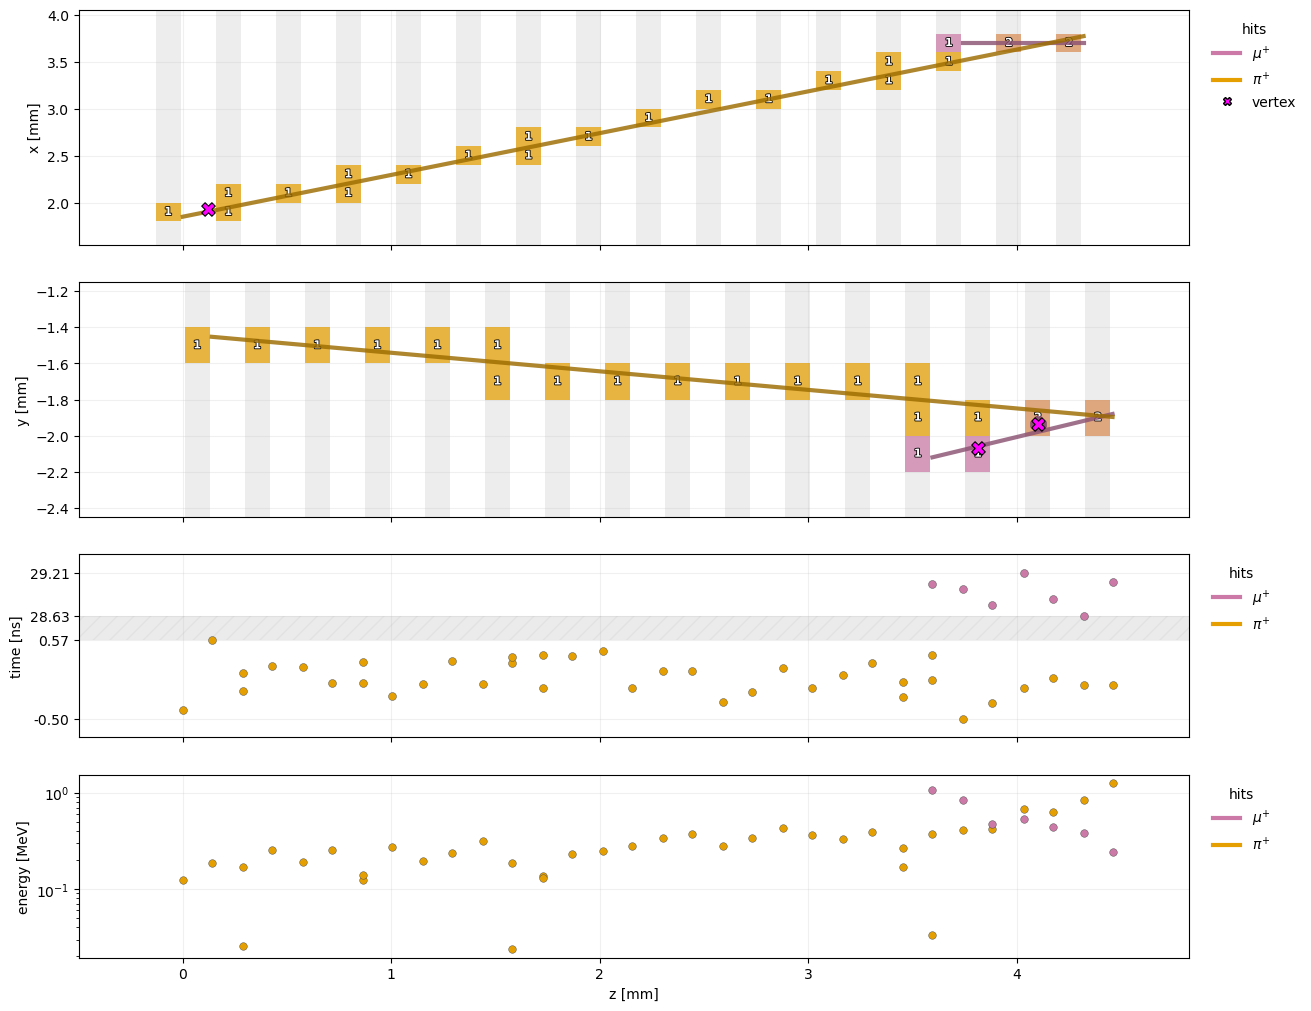

Event extra info: {'geo': <cppyy.gbl.PIGeoHeader object at 0x2a9640f0>, 'tracklet_algorithm_info': {'input_tracklets_count': 2, 'input_tracklet_ptrs_received': 2, 'particles_in_event_reco': Counter({-13: 1, 211: 1}), 'n_patterns_truth': 1, 'particles_in_event_truth': Counter({211: 1, -13: 1}), 'patterns_truth': {0: [0, 1]}}, 'vertex_algorithm_info': {'distance_threshold': 1.0, 'vertices_count': 3, 'input_tracklets_count': 2, 'single_endpoint_vertices': 3}}


In [10]:
pipeline.run_stage("vertices")
vertices = pipeline.get_storage()["vertices"]
event = pipeline.get_event()
print(f"Step 4 complete: {len(vertices)} vertices")
print(f"Current stage: {pipeline.get_current_stage()}")
EventDisplayFigure().draw(event)
print(f"Event extra info: {event.extra_info}")


## Step 5: form patterns

In [11]:
pipeline.run_stage("patterns")
patterns = pipeline.get_storage()["patterns"]
event = pipeline.get_event()
print(f"Step 5 complete: {len(patterns)} patterns")
print(f"Current stage: {pipeline.get_current_stage()}")

for pattern in patterns:
    print(f"\nPattern with {len(pattern.get_vertices())} vertices.")
    for vertex in pattern.get_vertices():
        tracklet_ids = [t.tracklet_id for t in vertex.get_tracklets()]
        print(f"  Vertex {vertex.vertex_id} (tracklet_ids={tracklet_ids})")
    print("  Unique Tracklets:")
    for tracklet in pattern.get_unique_tracklets():
        print(f"    {tracklet}")

print(f"\nEvent extra info: {event.extra_info}")


Step 5 complete: 2 patterns
Current stage: patterns

Pattern with 2 vertices.
  Vertex 0 (tracklet_ids=[0])
  Vertex 1 (tracklet_ids=[0])
  Unique Tracklets:
    Tracklet(id=0, particle_id=-13, e_id=0, hits=7, extra_info_keys=['raw_fit_result', 'fit_endpoints', 'display_endpoints', 'raw_tracklet'])

Pattern with 1 vertices.
  Vertex 2 (tracklet_ids=[1])
  Unique Tracklets:
    Tracklet(id=1, particle_id=211, e_id=0, hits=38, extra_info_keys=['raw_fit_result', 'fit_endpoints', 'display_endpoints', 'raw_tracklet'])

Event extra info: {'geo': <cppyy.gbl.PIGeoHeader object at 0x2adb8af0>, 'tracklet_algorithm_info': {'input_tracklets_count': 2, 'input_tracklet_ptrs_received': 2, 'particles_in_event_reco': Counter({-13: 1, 211: 1}), 'n_patterns_truth': 1, 'particles_in_event_truth': Counter({211: 1, -13: 1}), 'patterns_truth': {0: [0, 1]}}, 'vertex_algorithm_info': {'distance_threshold': 1.0, 'vertices_count': 3, 'input_tracklets_count': 2, 'single_endpoint_vertices': 3}, 'pattern_algorithm_

## Step 6: validate against truth collections

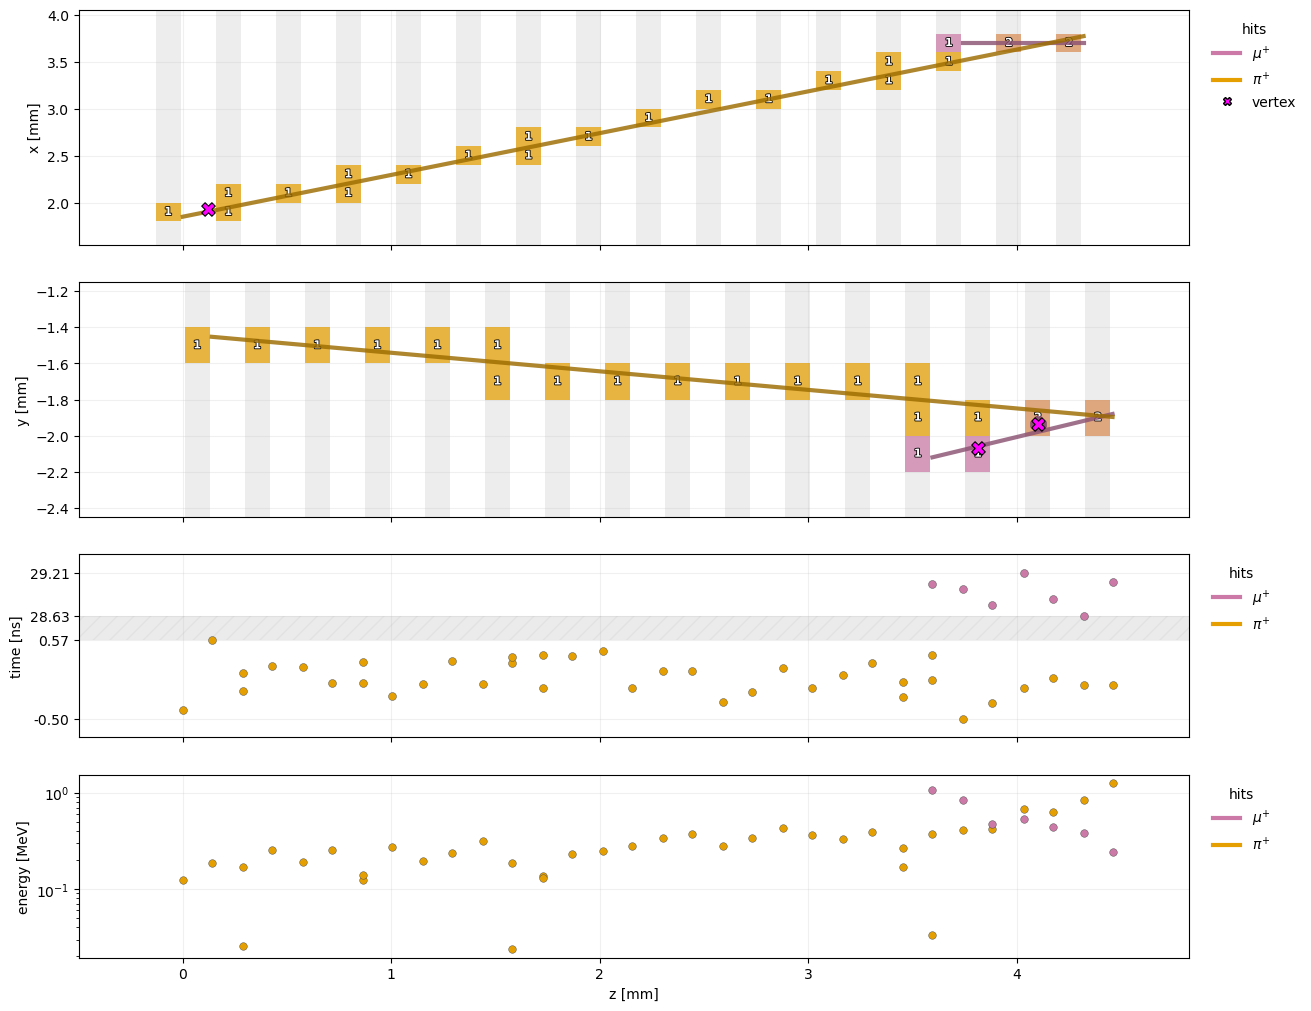

Step 6 complete: valid=False
Final event: Event(id=100, 2 patterns (sample IDs: ['Pattern(id=1, num_vertices=1)', 'Pattern(id=0, num_vertices=2)']), 2 tracklets (sample IDs: [1, 0]), 3 vertices (sample IDs: [2, 0, 1]), 45 hits, extra_info: 4 keys: ['geo', 'tracklet_algorithm_info', 'vertex_algorithm_info', 'pattern_algorithm_info'], is_valid=False)
Current stage: validation


In [12]:
pipeline.run_stage("validation")
event = pipeline.get_event()
EventDisplayFigure().draw(event)
print(f"Step 6 complete: valid={event.is_valid}")
print(f"Final event: {event}")
print(f"Current stage: {pipeline.get_current_stage()}")
